# Sweep Analysis — christiano_final_experiments

Analizza le run del grid search via WandB API.
Non richiede SUMO/env locale.

**Domande principali:**
1. Il reward model approssima bene la true reward?
2. Il PPO sta imparando bene?
3. Quali iperparametri contano di più?

In [25]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from collections import Counter

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

ENTITY  = "andrea02polimi-politecnico-di-milano"
PROJECT = "christiano_final_experiments"
CACHE   = Path("../data_for_training/sweep_cache.csv")  # evita di riscaricare ogni volta

In [57]:
# Debug: stampa tutte le chiavi del summary di un run campione
_api = wandb.Api(timeout=60)
_run = _api.run(f"{ENTITY}/{PROJECT}/{df_all['run_id'].iloc[0]}")
_s   = _run.summary._json_dict
print("Tutte le chiavi disponibili nel summary:\n")
for k in sorted(_s.keys()):
    print(f"  {k}")

Tutte le chiavi disponibili nel summary:

  _runtime
  _step
  _timestamp
  _wandb
  agent/action_rate/acc
  agent/action_rate/dec
  agent/action_rate/lcl
  agent/action_rate/lcr
  agent/action_rate/ss
  agent/event_rate/collisions
  agent/event_rate/off_road
  agent/event_rate/successes
  agent/event_rate/timeouts
  agent/performance/ep_avg_speed
  agent/performance/ep_duration
  agent/performance/ep_length
  agent/rewards/ep_comfort_return
  agent/rewards/ep_env_return
  agent/rewards/ep_fast_return
  agent/rollout/ep_len_mean
  agent/rollout/ep_rew_mean
  agent/time/fps
  agent/time/iterations
  agent/time/time_elapsed
  agent/time/total_timesteps
  agent/train/approx_kl
  agent/train/clip_fraction
  agent/train/clip_range
  agent/train/entropy_loss
  agent/train/explained_variance
  agent/train/learning_rate
  agent/train/loss
  agent/train/n_updates
  agent/train/policy_gradient_loss
  agent/train/std
  agent/train/value_loss
  dataset/n_train
  dataset/n_val
  dataset/train_arriv

## 1. Carica runs da WandB (con cache)

In [67]:
import json as _json

def _safe_get(d, *keys, default=np.nan):
    for k in keys:
        if not isinstance(d, dict) or k not in d:
            return default
        d = d[k]
    return d


def load_runs(force_reload=False):
    if CACHE.exists() and not force_reload:
        print(f"Caricato da cache: {CACHE}")
        return pd.read_csv(CACHE)

    print("Download runs da WandB API...")
    api  = wandb.Api(timeout=60)
    runs = api.runs(f"{ENTITY}/{PROJECT}")

    states = Counter(r.state for r in runs)
    print("Stato runs:")
    for state, n in sorted(states.items()):
        print(f"  {state:15s}: {n}")
    print(f"  {'TOTAL':15s}: {sum(states.values())}")

    rows = []
    for r in runs:
        # r da api.runs() è lazy: load_full_data() forza il fetch del config
        r.load_full_data()
        cfg = r.config
        s   = r.summary._json_dict

        row = {
            # ── identificatori ─────────────────────────────────────────────
            "run_id"   : r.id,
            "run_name" : r.name,
            "state"    : r.state,

            # ── iperparametri ───────────────────────────────────────────────
            "lr_rew"            : _safe_get(cfg, "algo", "kwargs", "lr_rew"),
            "gradient_steps_rew": _safe_get(cfg, "algo", "kwargs", "gradient_steps_rew"),
            "batch_size_rew"    : _safe_get(cfg, "algo", "kwargs", "batch_size_rew"),
            "fragment_length"   : _safe_get(cfg, "algo", "kwargs", "fragment_length"),
            "fragmenter_type"   : _safe_get(cfg, "algo", "kwargs", "fragmenter_type"),
            "labels_type"       : _safe_get(cfg, "algo", "kwargs", "labels_type"),
            "net_arch"          : str(_safe_get(cfg, "algo", "kwargs", "reward_model_kwargs", "net_arch")),
            "total_queries"     : _safe_get(cfg, "train", "kwargs", "total_queries"),

            # ── policy quality (prefisso "agent/" da PrefixedLogger) ────────
            "successes"         : s.get("agent/event_rate/successes",      np.nan),
            "timeouts"          : s.get("agent/event_rate/timeouts",       np.nan),
            "collisions"        : s.get("agent/event_rate/collisions",     np.nan),
            "ep_length"         : s.get("agent/performance/ep_length",     np.nan),
            "ep_avg_speed"      : s.get("agent/performance/ep_avg_speed",  np.nan),
            "ep_env_return"     : s.get("agent/rewards/ep_env_return",     np.nan),
            "ep_fast_return"    : s.get("agent/rewards/ep_fast_return",    np.nan),

            # ── reward model quality ────────────────────────────────────────
            "spearman_seg1"     : s.get("reward_correlation/spearman_seg1",    np.nan),
            "spearman_seg5"     : s.get("reward_correlation/spearman_seg5",    np.nan),
            "spearman_seg20"    : s.get("reward_correlation/spearman_seg20",   np.nan),
            "spearman_segNone"  : s.get("reward_correlation/spearman_segNone", np.nan),
            "acc_val"           : s.get("reward/acc_all_val",                  np.nan),
            "acc_train"         : s.get("reward/acc_all_train",                np.nan),
            "acc_gap"           : s.get("reward/acc_all_gap",                  np.nan),
            "loss_val"          : s.get("reward/loss_all_val",                 np.nan),

            # ── rollout diagnostics ─────────────────────────────────────────
            "mean_true_reward"  : s.get("rollout/mean_true_reward",            np.nan),
            "mean_model_reward" : s.get("rollout/mean_model_reward",           np.nan),

            # ── timing ──────────────────────────────────────────────────────
            "time_train_rew_model": s.get("time/train_reward_model",           np.nan),
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CACHE, index=False)
    print(f"Salvato in {CACHE}")
    return df


df_all = load_runs(force_reload=True)
df = df_all[df_all["state"] == "finished"].copy().reset_index(drop=True)
df["fragment_length"] = df["fragment_length"].fillna("None")
print(f"\nRun finite disponibili: {len(df)} / {len(df_all)}")
print("\nCheck valori HP per il primo run:")
print(df[["lr_rew","gradient_steps_rew","batch_size_rew","fragment_length",
          "fragmenter_type","labels_type","net_arch","total_queries"]].head(3).to_string())

Download runs da WandB API...
Stato runs:
  finished       : 199
  running        : 8
  TOTAL          : 207
Salvato in ../data_for_training/sweep_cache.csv

Run finite disponibili: 199 / 207

Check valori HP per il primo run:
   lr_rew  gradient_steps_rew  batch_size_rew fragment_length fragmenter_type      labels_type  net_arch  total_queries
0  0.0003                 100             100             1.0          active  binary_bernulli  [32, 32]          10000
1  0.0003                 100             100             1.0          active  binary_bernulli  [32, 32]         100000
2  0.0003                 100             100             1.0          active  binary_bernulli  [32, 32]          50000


## 2. Overview: top-20 configurazioni per success rate

In [47]:
HP_COLS     = ["lr_rew", "gradient_steps_rew", "batch_size_rew",
               "fragment_length", "fragmenter_type", "labels_type",
               "net_arch", "total_queries"]

METRIC_COLS = ["successes", "timeouts", "collisions",
               "spearman_seg1", "acc_val", "acc_gap"]

top20 = (
    df[df["acc_val"] > 0.8]
    .sort_values("successes", ascending=False)
    .head(20)
    .copy()
)

# aggiungi colonna con il link WandB
top20["wandb_link"] = top20["run_id"].apply(
    lambda rid: f"https://wandb.ai/{ENTITY}/{PROJECT}/runs/{rid}"
)

display_cols = HP_COLS + METRIC_COLS + ["wandb_link"]

top20[display_cols].style \
    .background_gradient(subset=["successes"], cmap="Greens") \
    .background_gradient(subset=["timeouts", "collisions"], cmap="Reds_r") \
    .background_gradient(subset=["spearman_seg1", "acc_val"], cmap="Blues") \
    .format({c: "{:.3f}" for c in METRIC_COLS}) \
    .format({"wandb_link": lambda x: f'<a href="{x}" target="_blank">run</a>'}) \
    .hide(axis="index")

lr_rew,gradient_steps_rew,batch_size_rew,fragment_length,fragmenter_type,labels_type,net_arch,total_queries,successes,timeouts,collisions,spearman_seg1,acc_val,acc_gap,wandb_link
0.000300,100,100,nan,active,soft,"[128, 128]",10000,1.000000,0.000000,0.000000,0.857768,0.909857,0.008104,run
0.000300,100,100,nan,random,soft,"[128, 128]",10000,1.000000,0.000000,0.000000,0.857509,0.903431,0.001719,run
0.000300,100,100,1.000000,active,soft,"[128, 128]",10000,0.954545,0.000000,0.045455,0.815618,0.928431,-0.003934,run
0.000300,100,500,1.000000,active,soft,"[128, 128]",10000,0.952381,0.000000,0.047619,0.815809,0.962745,-0.005459,run
0.000300,100,500,25.000000,random,soft,"[128, 128]",10000,0.950000,0.000000,0.050000,0.856447,0.900490,0.001143,run
0.000300,100,500,nan,random,soft,"[32, 32]",10000,0.947368,0.000000,0.052632,0.852728,0.926961,-0.014272,run
0.000300,300,100,2.000000,random,soft,"[128, 128]",10000,0.923077,0.000000,0.076923,0.814270,0.935784,-0.005257,run
0.000300,300,500,1.000000,active,soft,"[128, 128]",10000,0.916667,0.000000,0.083333,0.815809,0.962255,0.001439,run
0.000300,100,100,2.000000,random,soft,"[128, 128]",10000,0.916667,0.000000,0.083333,0.815060,0.928431,-0.002175,run
0.000300,100,500,25.000000,active,soft,"[32, 32]",10000,0.909091,0.000000,0.090909,0.855670,0.826471,-0.008129,run


In [52]:
HP_COLS     = ["lr_rew", "gradient_steps_rew", "batch_size_rew",
               "fragment_length", "fragmenter_type", "labels_type",
               "net_arch", "total_queries"]
METRIC_COLS = ["successes", "timeouts", "collisions",
               "spearman_seg1", "acc_val", "acc_gap"]

#top20 = df.sort_values("successes", ascending=False).head(20)
#top20 = df.sort_values("successes", ascending=False).tail(100)
top20 = (
    df[df["acc_val"] < 0.6]
    .sort_values("successes", ascending=False)
    .head(20)
)

display_cols = HP_COLS + METRIC_COLS
top20[display_cols].style \
    .background_gradient(subset=["successes"], cmap="Greens") \
    .background_gradient(subset=["timeouts", "collisions"], cmap="Reds_r") \
    .background_gradient(subset=["spearman_seg1", "acc_val"], cmap="Blues") \
    .format({c: "{:.3f}" for c in METRIC_COLS})

,lr_rew,gradient_steps_rew,batch_size_rew,fragment_length,fragmenter_type,labels_type,net_arch,total_queries,successes,timeouts,collisions,spearman_seg1,acc_val,acc_gap
81,0.000300,100,500,2.000000,active,binary_bernulli,"[128, 128]",100000,1.000,0.000,0.000,0.799,0.506,0.009
137,0.000300,300,100,1.000000,random,binary_bernulli,"[128, 128]",100000,0.957,0.000,0.043,0.800,0.500,0.013
61,0.000300,100,100,nan,random,binary_bernulli,"[32, 32]",100000,0.950,0.000,0.050,0.703,0.545,0.002
143,0.000300,300,100,1.000000,random,binary_bernulli,"[32, 32]",10000,0.917,0.000,0.083,0.796,0.510,0.039
105,0.000300,100,500,25.000000,random,binary_bernulli,"[128, 128]",100000,0.917,0.000,0.083,0.844,0.505,0.008
17,0.000300,100,100,2.000000,active,binary_bernulli,"[128, 128]",100000,0.900,0.000,0.100,0.794,0.507,0.004
130,0.000300,300,100,1.000000,active,binary_bernulli,"[128, 128]",50000,0.889,0.000,0.111,0.812,0.513,0.010
173,0.000300,300,100,25.000000,random,binary_bernulli,"[32, 32]",100000,0.875,0.000,0.125,0.814,0.505,0.012
23,0.000300,100,100,2.000000,active,binary_bernulli,"[32, 32]",10000,0.867,0.000,0.133,0.787,0.498,0.045
185,0.000300,300,100,nan,random,binary_bernulli,"[128, 128]",100000,0.857,0.000,0.143,0.748,0.538,0.007


## 3. RM quality vs Policy quality

Se il RM approssima bene la true reward, ci aspettiamo che `spearman_seg1` alto → `successes` alto.

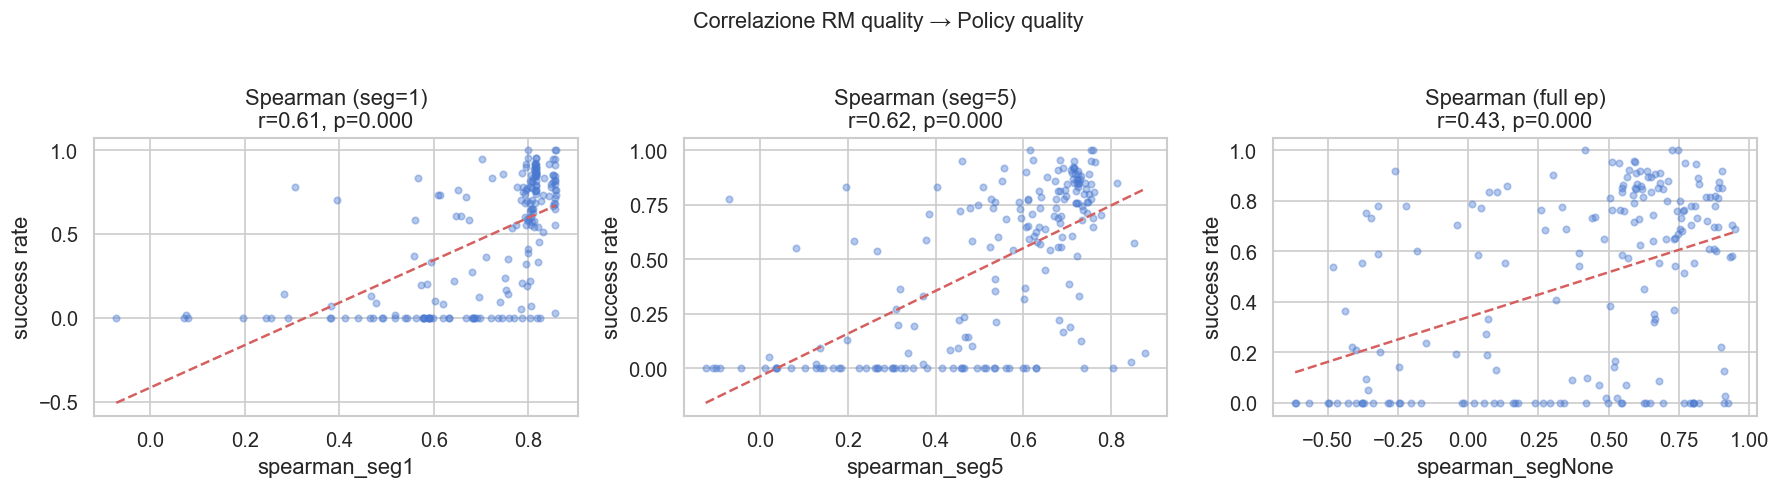

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

spearman_cols = ["spearman_seg1", "spearman_seg5", "spearman_segNone"]
titles        = ["Spearman (seg=1)", "Spearman (seg=5)", "Spearman (full ep)"]

for ax, scol, title in zip(axes, spearman_cols, titles):
    mask = df[scol].notna() & df["successes"].notna()
    ax.scatter(df.loc[mask, scol], df.loc[mask, "successes"],
               alpha=0.4, s=15)
    # linea di correlazione
    x = df.loc[mask, scol]
    y = df.loc[mask, "successes"]
    if len(x) > 1:
        m, b = np.polyfit(x, y, 1)
        rng = np.linspace(x.min(), x.max(), 100)
        ax.plot(rng, m * rng + b, "r--", lw=1.5)
        from scipy.stats import pearsonr
        r, p = pearsonr(x, y)
        ax.set_title(f"{title}\nr={r:.2f}, p={p:.3f}")
    else:
        ax.set_title(title)
    ax.set_xlabel(scol)
    ax.set_ylabel("success rate")

plt.suptitle("Correlazione RM quality → Policy quality", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 4. Analisi marginale per iperparametro

Marginalizza su tutti gli altri hp: qual è l'effetto di ogni singolo iperparametro su `successes` e `spearman_seg1`?

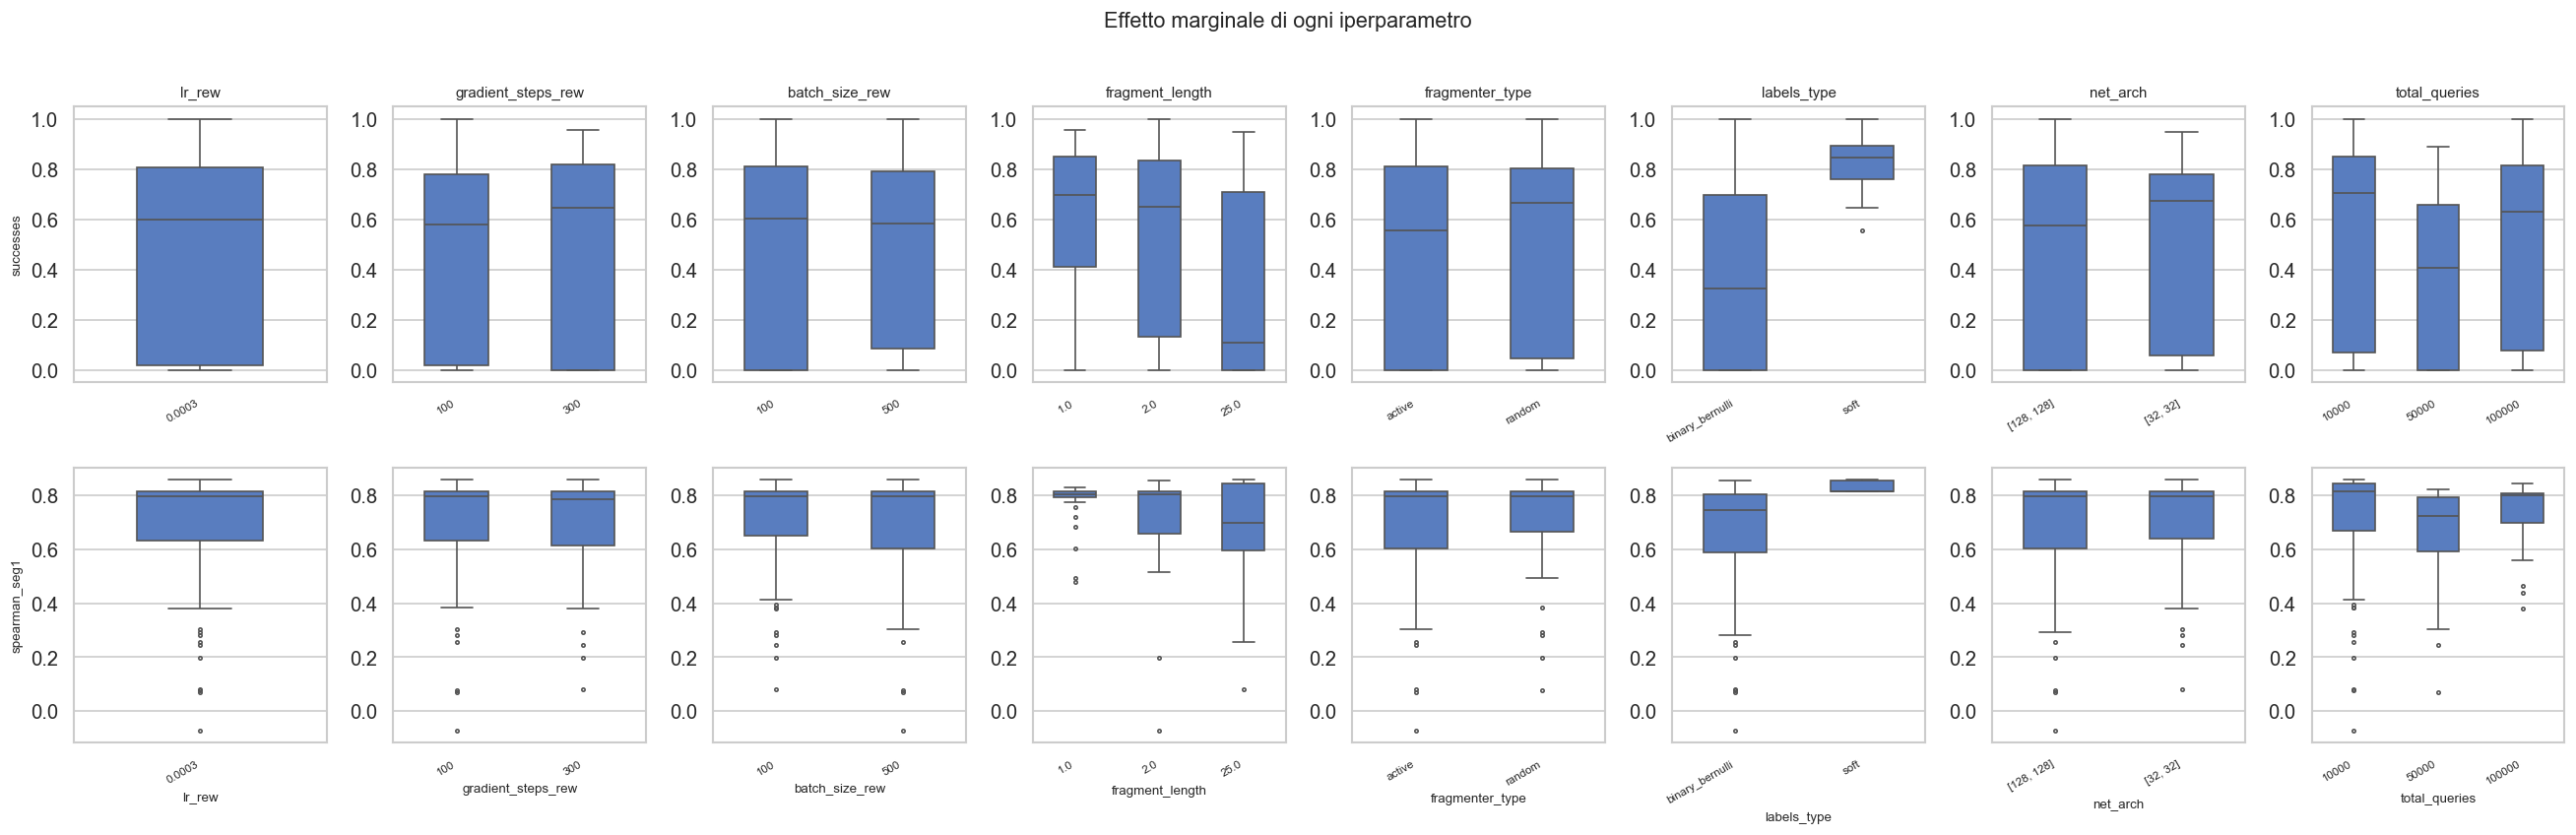

In [49]:
fig, axes = plt.subplots(2, len(HP_COLS), figsize=(22, 7))

for col_idx, hp in enumerate(HP_COLS):
    for row_idx, metric in enumerate(["successes", "spearman_seg1"]):
        ax = axes[row_idx, col_idx]
        sub = df[[hp, metric]].dropna()

        order = sorted(sub[hp].unique(), key=lambda x: (str(type(x)), x))
        sns.boxplot(data=sub, x=hp, y=metric, order=order, ax=ax,
                    width=0.5, fliersize=2)
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)
        ax.set_xlabel(hp if row_idx == 1 else "", fontsize=8)
        ax.set_ylabel(metric if col_idx == 0 else "", fontsize=8)
        ax.set_title(hp if row_idx == 0 else "", fontsize=9)

plt.suptitle("Effetto marginale di ogni iperparametro", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Heatmap pairwise: fragment_length × labels_type

Le due dimensioni più interessanti per il RM: quanto lungo è il frammento e che tipo di label usi.

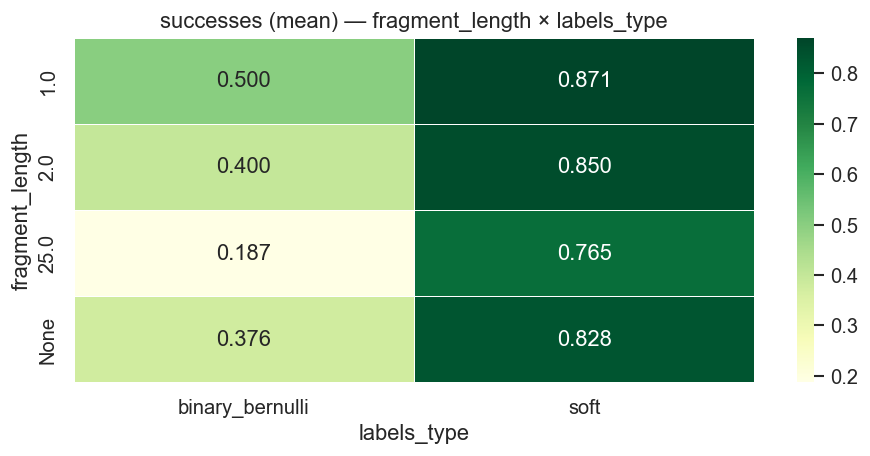

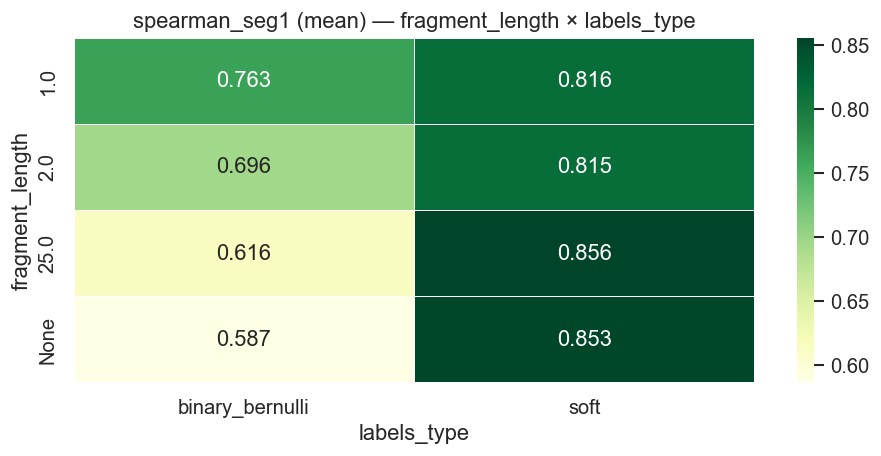

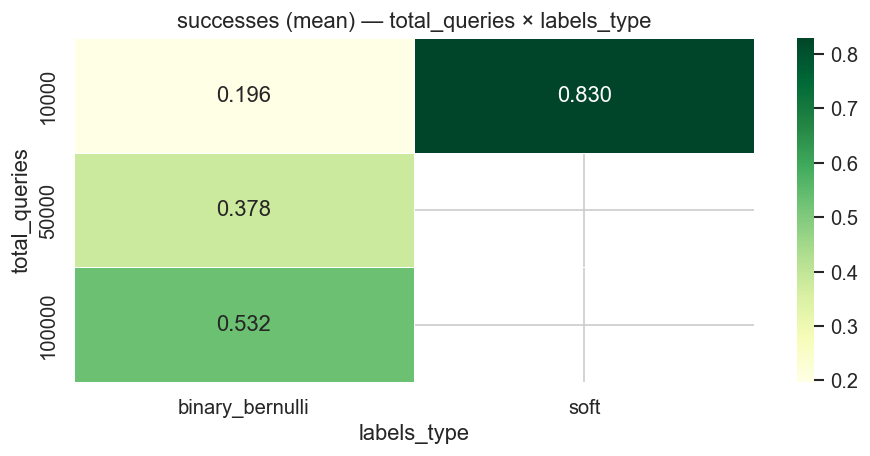

In [62]:
def pairwise_heatmap(df, hp1, hp2, metric, agg="mean", figsize=(8, 4)):
    plot_df = df.copy()
    plot_df[hp1] = plot_df[hp1].fillna("None")
    plot_df[hp2] = plot_df[hp2].fillna("None")
    pivot = plot_df.groupby([hp1, hp2], dropna=False)[metric].agg(agg).unstack(hp2)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn",
                linewidths=0.5, ax=ax)
    ax.set_title(f"{metric} ({agg}) — {hp1} × {hp2}")
    plt.tight_layout()
    plt.show()


pairwise_heatmap(df, "fragment_length", "labels_type", "successes")
pairwise_heatmap(df, "fragment_length", "labels_type", "spearman_seg1")
pairwise_heatmap(df, "total_queries",   "labels_type", "successes")

## 6. Heatmap: gradient_steps_rew × batch_size_rew

Budget di training del reward model.

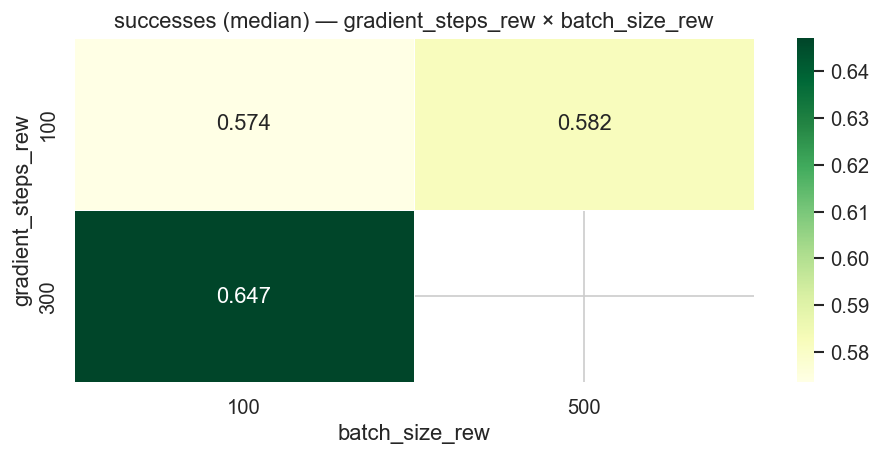

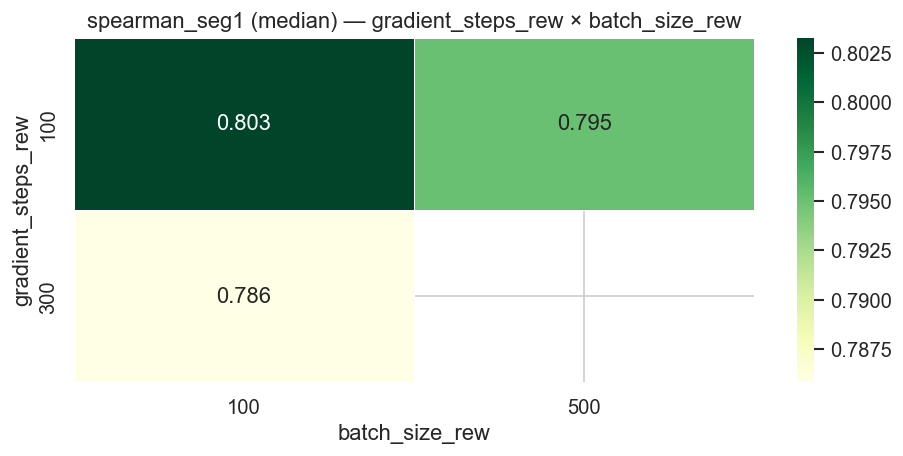

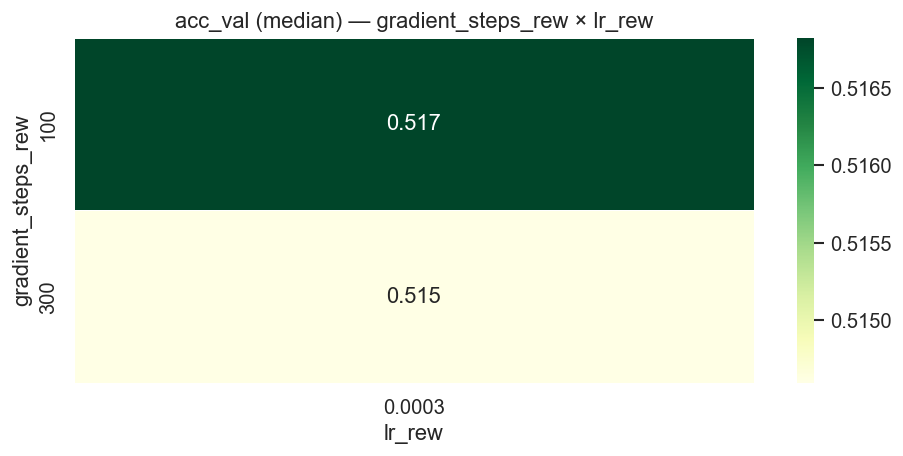

In [33]:
pairwise_heatmap(df, "gradient_steps_rew", "batch_size_rew", "successes")
pairwise_heatmap(df, "gradient_steps_rew", "batch_size_rew", "spearman_seg1")
pairwise_heatmap(df, "gradient_steps_rew", "lr_rew",         "acc_val")

## 7. Parallel Coordinates

Visualizzazione compatta di tutte le dimensioni HP contemporaneamente.
Colora per `successes`: verde = buono, rosso = cattivo.
Seleziona le top-N run per ridurre il rumore.

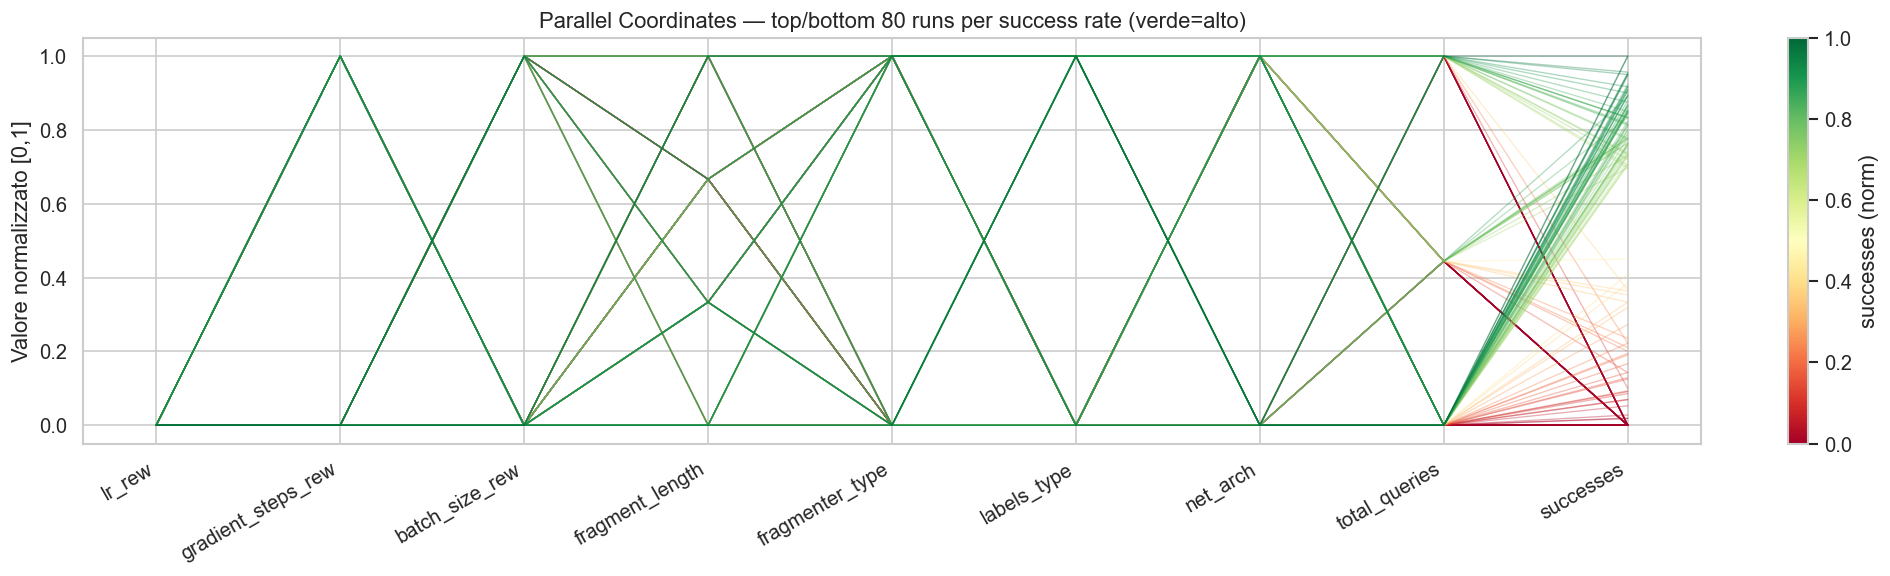

In [34]:
TOP_N = 80  # mostra le migliori 80 + peggiori 80 per contrasto

df_sorted   = df.dropna(subset=["successes"]).sort_values("successes")
df_contrast = pd.concat([df_sorted.head(TOP_N), df_sorted.tail(TOP_N)])

# Encode categorici come interi per il plot
enc = df_contrast.copy()
for col in ["fragmenter_type", "labels_type", "net_arch"]:
    enc[col] = pd.Categorical(enc[col]).codes
enc["fragment_length"] = enc["fragment_length"].astype(str)  # null → stringa
enc["fragment_length"] = pd.Categorical(enc["fragment_length"]).codes

pc_cols = ["lr_rew", "gradient_steps_rew", "batch_size_rew",
           "fragment_length", "fragmenter_type", "labels_type",
           "net_arch", "total_queries", "successes"]

# Normalizza ogni asse in [0,1]
plot_df = enc[pc_cols].copy()
for col in pc_cols:
    col_range = plot_df[col].max() - plot_df[col].min()
    if col_range > 0:
        plot_df[col] = (plot_df[col] - plot_df[col].min()) / col_range

colors = cm.RdYlGn(plot_df["successes"].values)

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(pc_cols))
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.plot(x, row[pc_cols].values, color=colors[i], alpha=0.35, lw=0.8)

ax.set_xticks(x)
ax.set_xticklabels(pc_cols, rotation=30, ha="right")
ax.set_ylabel("Valore normalizzato [0,1]")
ax.set_title(f"Parallel Coordinates — top/bottom {TOP_N} runs per success rate (verde=alto)")

sm = plt.cm.ScalarMappable(cmap="RdYlGn",
                            norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, ax=ax, fraction=0.015, label="successes (norm)")
plt.tight_layout()
plt.show()

## 8. Tracking: true reward vs model reward nel tempo

Per capire se il RM "segue" la true reward durante il training,
scarica la history per le top-K run e plotta `rollout/mean_true_reward`
vs `rollout/mean_model_reward` su stesso asse (scale diverse → twin axis).

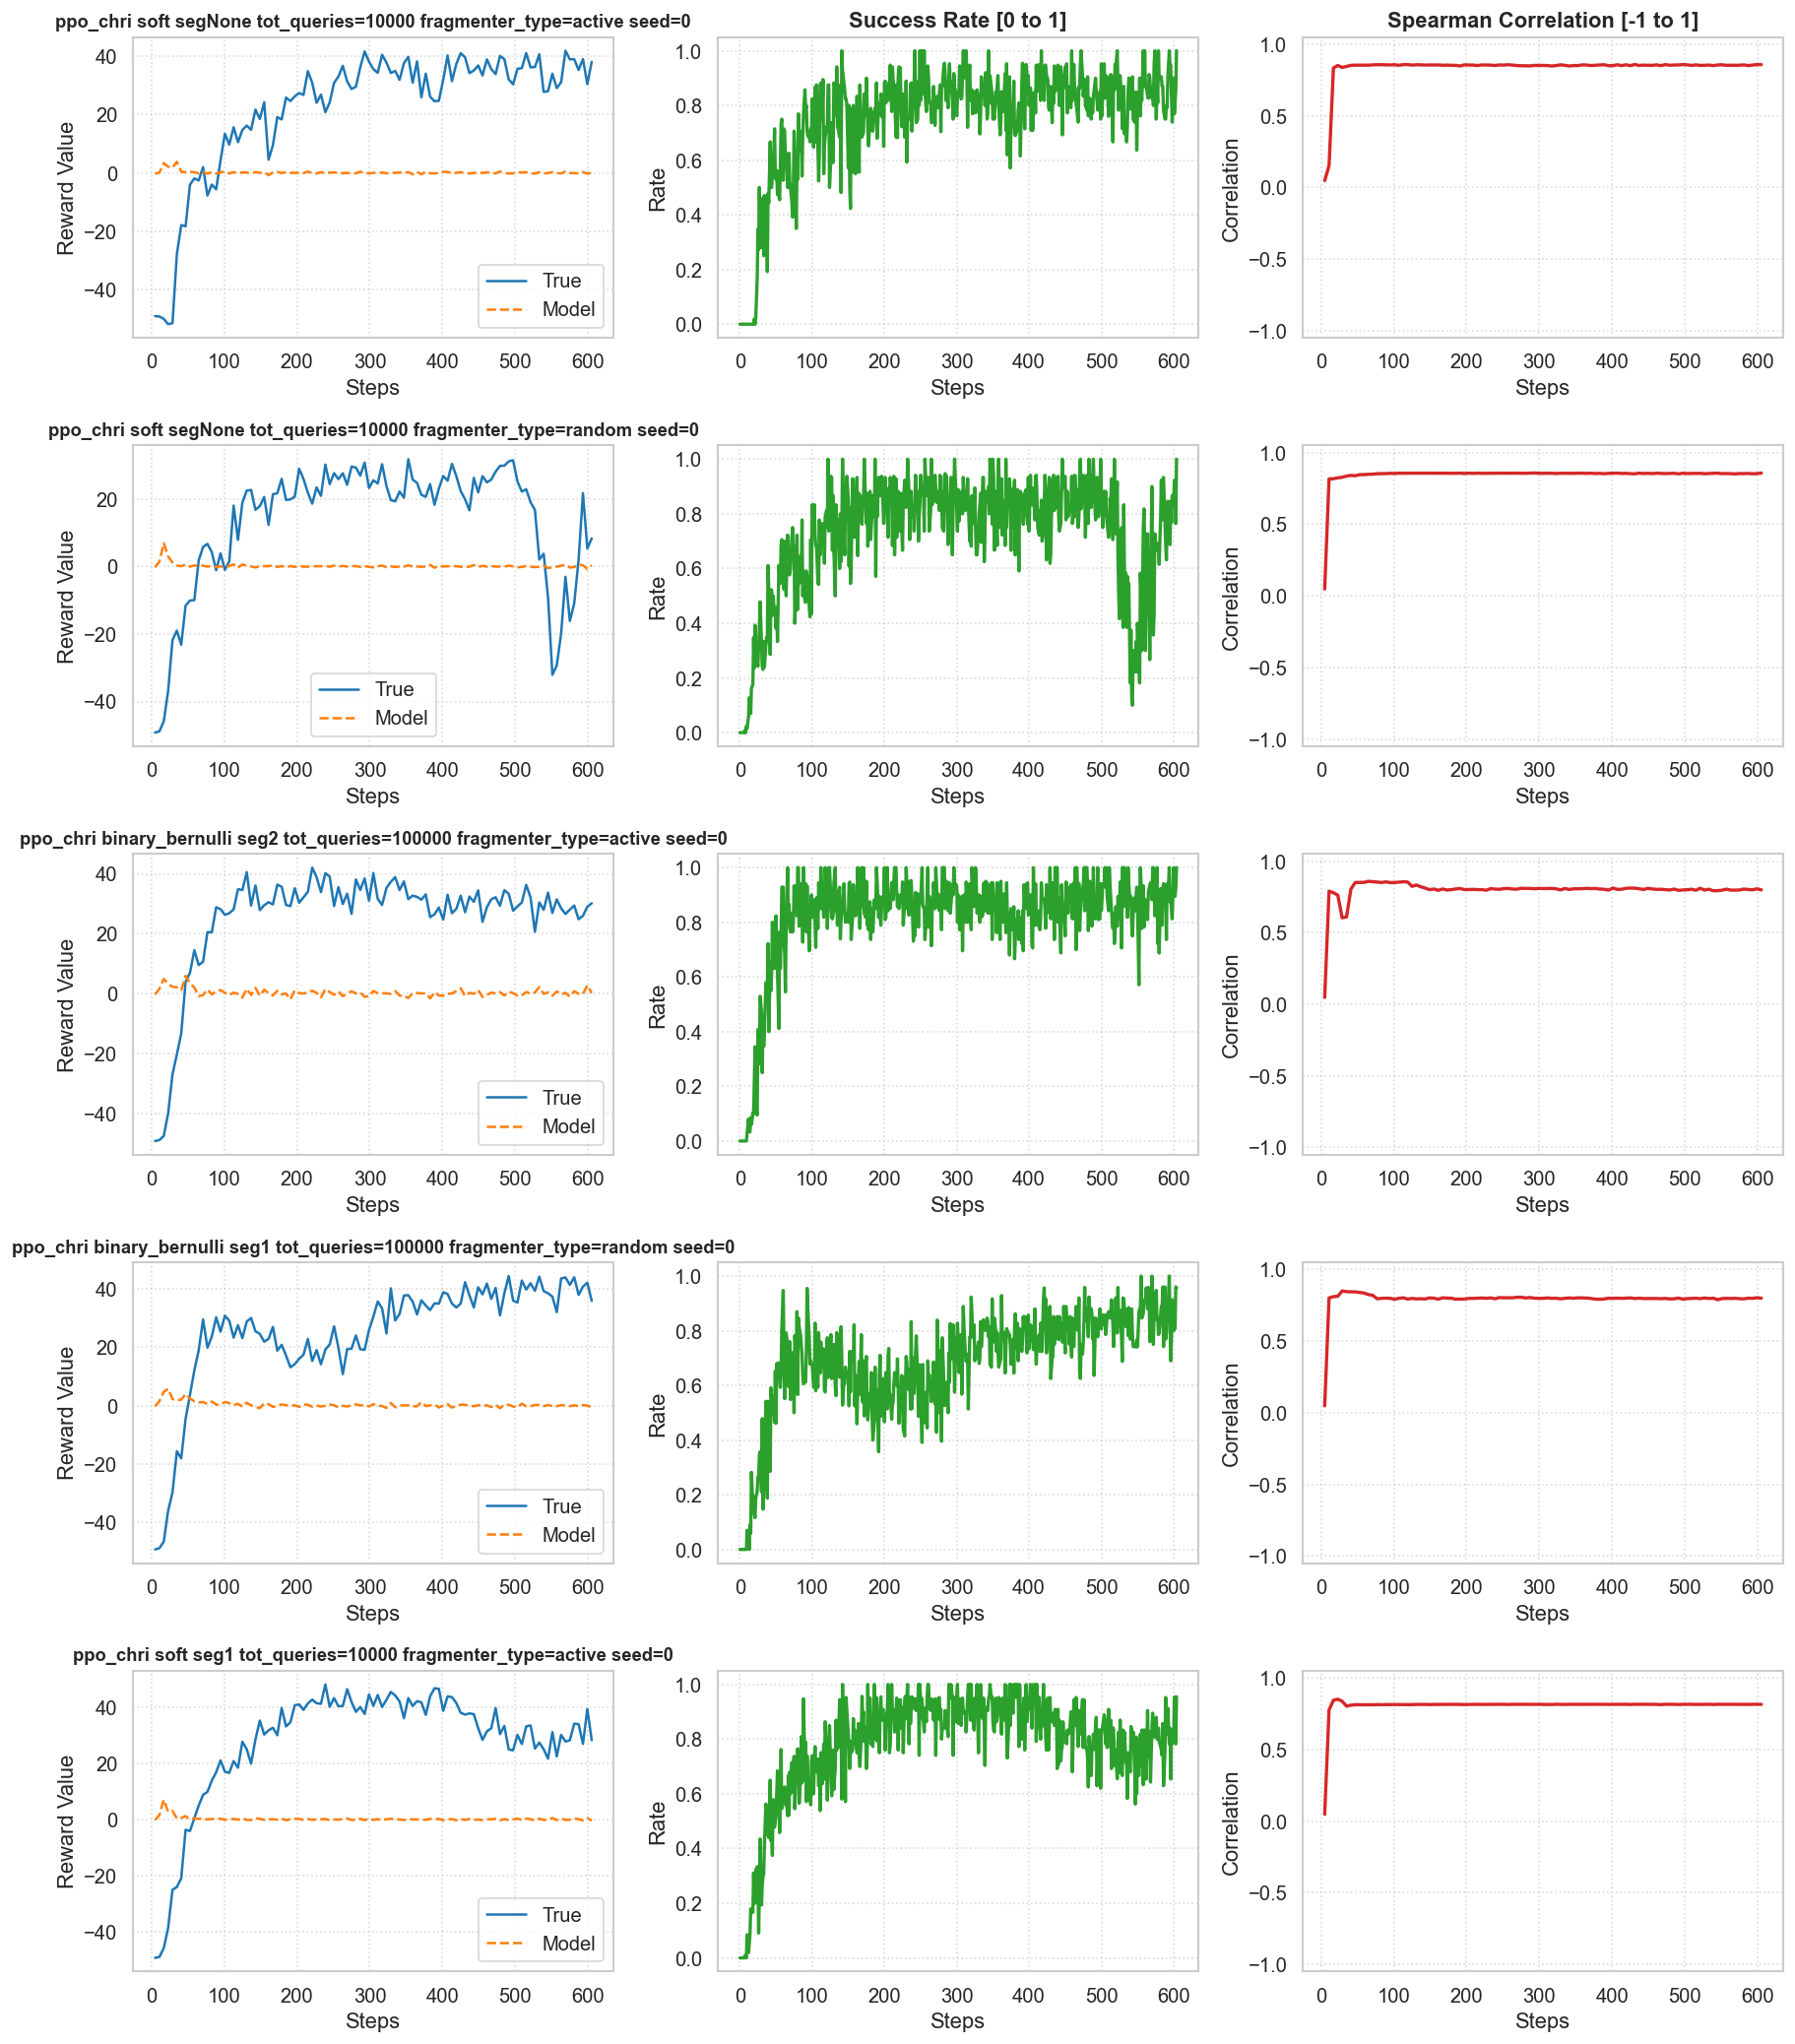

In [45]:
from wandb import api
import matplotlib.pyplot as plt

TOP_K_HISTORY = 5

api = wandb.Api(timeout=60)
top_k = df.nlargest(TOP_K_HISTORY, "successes")[["run_id", "run_name", "successes"]]

# nomi corretti nella history
COL_TRUE = "rollout/mean_true_reward"
COL_MODEL = "rollout/mean_model_reward"
COL_SUCC = "agent/event_rate/successes"
COL_SPR = "reward_correlation/spearman_seg1"

# Creiamo una griglia: 5 righe (una per run) x 3 colonne (tematiche)
fig, axes = plt.subplots(TOP_K_HISTORY, 3, figsize=(15, 3.5 * TOP_K_HISTORY))

# Assicuriamoci che axes sia iterabile come lista di righe anche se TOP_K_HISTORY = 1
if TOP_K_HISTORY == 1:
    axes = [axes]

for i, (row_axes, (_, row)) in enumerate(zip(axes, top_k.iterrows())):
    # Decomponiamo i 3 grafici per la riga (run) corrente
    ax_rew, ax_succ, ax_corr = row_axes

    run = api.run(f"{ENTITY}/{PROJECT}/{row['run_id']}")
    hist = run.history(samples=1000)

    # --- COLONNA 1: REWARDS (True vs Model) ---
    if COL_TRUE in hist.columns:
        sub = hist[["_step", COL_TRUE]].dropna().sort_values("_step")
        ax_rew.plot(sub["_step"], sub[COL_TRUE], label="True", color="#1f77b4", lw=1.5)
    if COL_MODEL in hist.columns:
        sub = hist[["_step", COL_MODEL]].dropna().sort_values("_step")
        ax_rew.plot(sub["_step"], sub[COL_MODEL], label="Model", color="#ff7f0e", ls="--", lw=1.5)

    ax_rew.set_ylabel("Reward Value")
    ax_rew.set_title(f"{row['run_name']}", fontweight="bold", fontsize=11)
    ax_rew.legend(loc="best", frameon=True)

    # --- COLONNA 2: SUCCESS RATE ---
    if COL_SUCC in hist.columns:
        sub = hist[["_step", COL_SUCC]].dropna().sort_values("_step")
        ax_succ.plot(sub["_step"], sub[COL_SUCC], color="#2ca02c", lw=2)

    ax_succ.set_ylim(-0.05, 1.05)
    ax_succ.set_ylabel("Rate")
    # Mettiamo il titolo descrittivo solo sulla prima riga per non ripetere
    if i == 0: ax_succ.set_title("Success Rate [0 to 1]", fontweight="bold")

    # --- COLONNA 3: SPEARMAN CORRELATION ---
    if COL_SPR in hist.columns:
        sub = hist[["_step", COL_SPR]].dropna().sort_values("_step")
        ax_corr.plot(sub["_step"], sub[COL_SPR], color="#d62728", lw=2)

    ax_corr.set_ylim(-1.05, 1.05)
    ax_corr.set_ylabel("Correlation")
    if i == 0: ax_corr.set_title("Spearman Correlation [-1 to 1]", fontweight="bold")

    # --- FORMATTAZIONE COMUNE PER TUTTI I GRAFICI ---
    for ax in row_axes:
        ax.set_xlabel("Steps")
        ax.grid(True, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.show()

## 9. Diagnostica overfitting RM

`acc_gap = acc_train - acc_val` positivo = overfitting.
Interessante vedere se overfitting correla con scarsa policy.

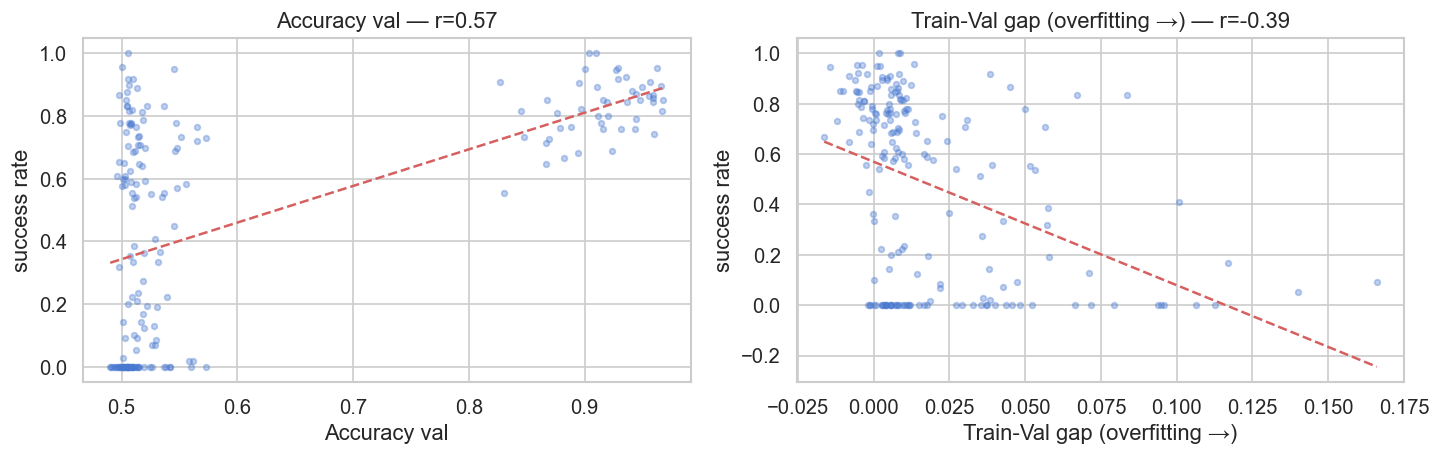

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (x_col, x_label) in zip(axes, [("acc_val", "Accuracy val"),
                                         ("acc_gap", "Train-Val gap (overfitting →)"),]):
    mask = df[x_col].notna() & df["successes"].notna()
    ax.scatter(df.loc[mask, x_col], df.loc[mask, "successes"], alpha=0.35, s=12)
    ax.set_xlabel(x_label)
    ax.set_ylabel("success rate")
    # best fit line
    x, y = df.loc[mask, x_col], df.loc[mask, "successes"]
    if len(x) > 1:
        m, b = np.polyfit(x, y, 1)
        rng = np.linspace(x.min(), x.max(), 100)
        ax.plot(rng, m * rng + b, "r--", lw=1.5)
        from scipy.stats import pearsonr
        r, _ = pearsonr(x, y)
        ax.set_title(f"{x_label} — r={r:.2f}")

plt.tight_layout()
plt.show()

## 10. Feature importance rapida (Random Forest)

Quale HP spiega più varianza in `successes`? Ordinato per importanza.

i valori più in alto hanno aiutato più spesso a separare i successi dai fallimenti

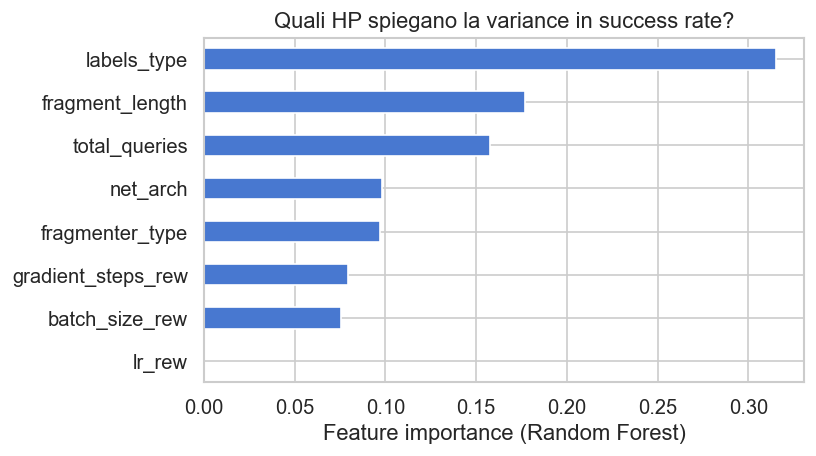


Top HP per importanza:
labels_type           0.315088
fragment_length       0.177129
total_queries         0.157489
net_arch              0.098146
fragmenter_type       0.097171
gradient_steps_rew    0.079295
batch_size_rew        0.075681
lr_rew                0.000000


In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

sub = df[HP_COLS + ["successes"]].dropna()

X = sub[HP_COLS].copy()
for col in ["fragmenter_type", "labels_type", "net_arch"]:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))
X["fragment_length"] = pd.to_numeric(X["fragment_length"], errors="coerce").fillna(-1)

y = sub["successes"].values

rf = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=HP_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importance.plot.barh(ax=ax)
ax.set_xlabel("Feature importance (Random Forest)")
ax.set_title("Quali HP spiegano la variance in success rate?")
plt.tight_layout()
plt.show()

print("\nTop HP per importanza:")
print(importance[::-1].to_string())

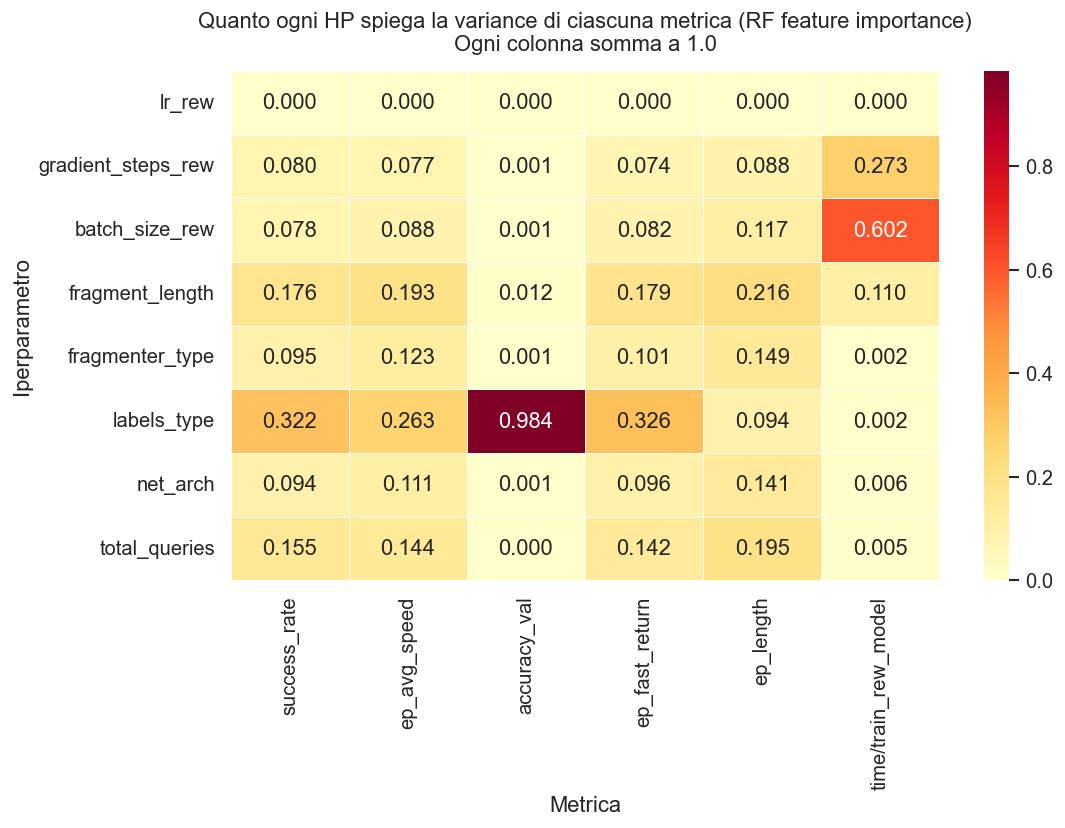

In [59]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Mappa nome display → colonna nel df
TARGET_METRICS = {
    "success_rate":          "successes",
    "ep_avg_speed":          "ep_avg_speed",
    "accuracy_val":          "acc_val",
    "ep_fast_return":        "ep_fast_return",
    "ep_length":             "ep_length",
    "time/train_rew_model":  "time_train_rew_model",
}

available = {label: col for label, col in TARGET_METRICS.items() if col in df.columns}
missing   = [label for label, col in TARGET_METRICS.items() if col not in df.columns]
if missing:
    print(f"Metriche non presenti nel df (skip): {missing}")

def _encode_hp(sub_df):
    X = sub_df[HP_COLS].copy()
    for col in ["fragmenter_type", "labels_type", "net_arch"]:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    X["fragment_length"] = pd.to_numeric(X["fragment_length"], errors="coerce").fillna(-1)
    return X

rows = {}
for label, col in available.items():
    sub = df[HP_COLS + [col]].dropna()
    if len(sub) < 10:
        print(f"Troppo pochi campioni per '{label}' ({len(sub)}), skip.")
        continue
    X = _encode_hp(sub)
    y = sub[col].values
    rf = RandomForestRegressor(n_estimators=200, random_state=0, n_jobs=-1)
    rf.fit(X, y)
    rows[label] = pd.Series(rf.feature_importances_, index=HP_COLS)

imp_df = pd.DataFrame(rows)   # righe = HP, colonne = metriche

fig, ax = plt.subplots(figsize=(max(6, len(imp_df.columns) * 1.6), len(HP_COLS) * 0.7 + 1.5))
sns.heatmap(
    imp_df,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    vmin=0,
    vmax=imp_df.values.max(),
    ax=ax,
)
ax.set_title("Quanto ogni HP spiega la variance di ciascuna metrica (RF feature importance)\n"
             "Ogni colonna somma a 1.0", pad=12)
ax.set_xlabel("Metrica")
ax.set_ylabel("Iperparametro")
plt.tight_layout()
plt.show()

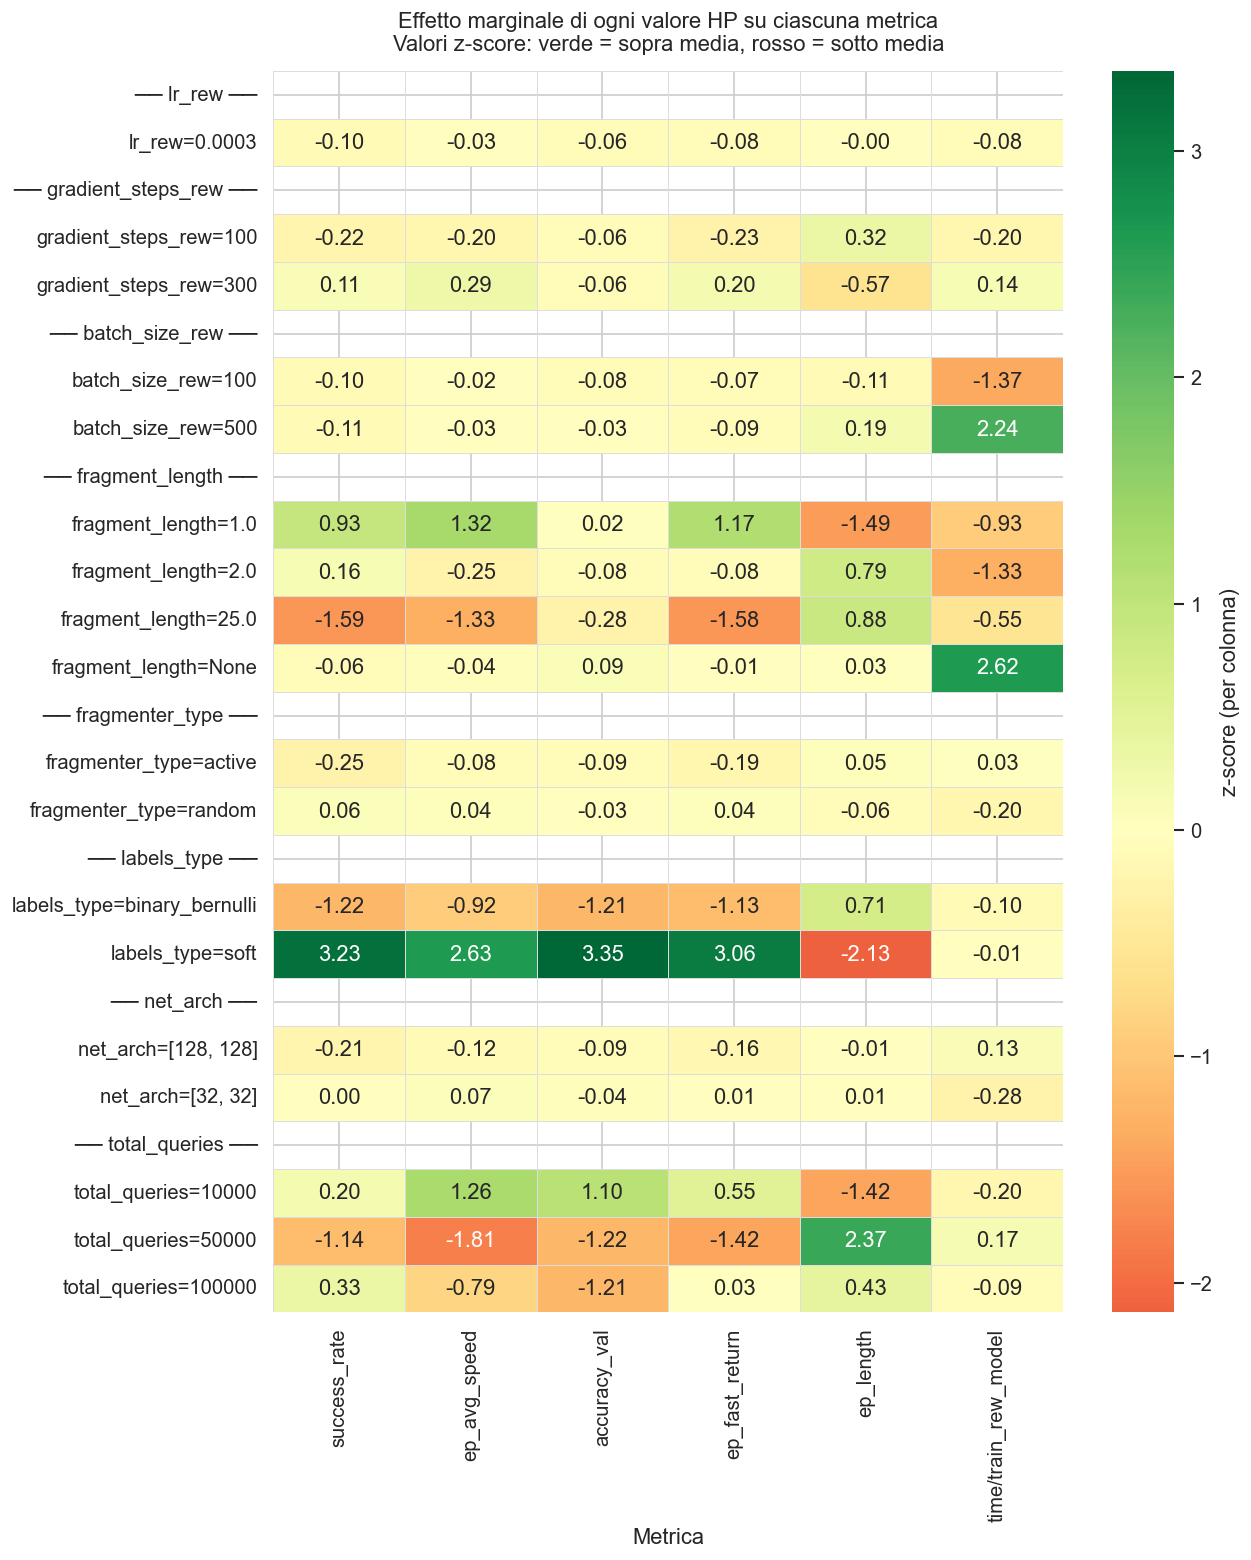

In [68]:
from sklearn.preprocessing import LabelEncoder

# Stessi target della cella sopra — usa quelli disponibili
available_metrics = {label: col for label, col in TARGET_METRICS.items() if col in df.columns}

# Costruisce le righe: una per ogni (hp, valore) unico
records = []
for hp in HP_COLS:
    for val in sorted(df[hp].dropna().unique(), key=lambda x: (str(type(x)), x)):
        mask = df[hp] == val
        row = {"HP": hp, "valore": str(val), "label": f"{hp}={val}"}
        for label, col in available_metrics.items():
            row[label] = df.loc[mask, col].mean()
        records.append(row)

marginal_df = pd.DataFrame(records).set_index("label")
metric_cols  = list(available_metrics.keys())

# Normalizza ogni colonna con z-score per rendere i colori comparabili tra metriche
norm_df = marginal_df[metric_cols].copy()
for col in metric_cols:
    std = norm_df[col].std()
    norm_df[col] = (norm_df[col] - norm_df[col].mean()) / std if std > 0 else 0.0

# Separa i blocchi per HP con una riga vuota visiva (NaN) — migliora la leggibilità
spacer_rows = {}
blocks = []
for hp in HP_COLS:
    block = norm_df[[r.startswith(f"{hp}=") for r in norm_df.index]]
    spacer = pd.DataFrame([[np.nan] * len(metric_cols)],
                          columns=metric_cols, index=[f"── {hp} ──"])
    blocks.extend([spacer, block])
plot_df = pd.concat(blocks)

fig, ax = plt.subplots(figsize=(max(7, len(metric_cols) * 1.8), len(plot_df) * 0.45 + 1.5))
sns.heatmap(
    plot_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.4,
    linecolor="#dddddd",
    ax=ax,
    cbar_kws={"label": "z-score (per colonna)"},
)
ax.set_title("Effetto marginale di ogni valore HP su ciascuna metrica\n"
             "Valori z-score: verde = sopra media, rosso = sotto media", pad=12)
ax.set_xlabel("Metrica")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 11. Riepilogo: migliore configurazione

Stampa la configurazione con il success rate più alto.

In [43]:
best = df.sort_values("successes", ascending=False).iloc[0]
print("=" * 50)
print("MIGLIORE CONFIGURAZIONE")
print("=" * 50)
for hp in HP_COLS:
    print(f"  {hp:25s}: {best[hp]}")
print()
print("METRICHE FINALI")
print("-" * 50)
for m in METRIC_COLS:
    print(f"  {m:25s}: {best[m]:.4f}")
print(f"\n  WandB run: https://wandb.ai/{ENTITY}/{PROJECT}/runs/{best['run_id']}")

MIGLIORE CONFIGURAZIONE
  lr_rew                   : 0.0003
  gradient_steps_rew       : 100
  batch_size_rew           : 100
  fragment_length          : nan
  fragmenter_type          : random
  labels_type              : soft
  net_arch                 : [128, 128]
  total_queries            : 10000

METRICHE FINALI
--------------------------------------------------
  successes                : 1.0000
  timeouts                 : 0.0000
  collisions               : 0.0000
  spearman_seg1            : 0.8575
  acc_val                  : 0.9034
  acc_gap                  : 0.0017

  WandB run: https://wandb.ai/andrea02polimi-politecnico-di-milano/christiano_final_experiments/runs/h0vk3pqy
